This program contains the Python code for the example presented in the paper *Existence of Extremal Solutions for Caputo Fractional Differential Equations with Bounded Delay published in 2023 in the journal *Progress in Fractional Differentiation and Applications*.

The paper can be found in [this link](https://www.naturalspublishing.com/files/published/227rai755t2y01.pdf)

In [ ]:
from sympy import Symbol, symbols, integrate, Integral, Piecewise, Limit, simplify, lambdify
from sympy.plotting import plot
from fractions import Fraction
from numpy import linspace
import torch
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
t = Symbol('t')
x = Symbol('x')
s = Symbol('s')

def v0(t):
    return 0

def w0(t):
    return 1

In [ ]:
"""
def v1(t):
    v10=Fraction(1,5)*w0+Fraction(1,4)*integrate((1+s**2)*w0,s)**2-Fraction(1,3)*v0**2-Fraction(1,8)*integrate((1+s**2)*v0,s)
    return Fraction(1,2)+(1/sp.sqrt(sp.pi))*integrate((t-s)**(-Fraction(1,2))*v10,(s,0,t))
"""

def v1(t):
    v10=Fraction(1,3)*w0(x)+Fraction(1,10)*(integrate((1+x**2)*w0(x),(x,0,s)))**2-Fraction(1,4)*v0(x)**2-Fraction(1,6)*integrate((1+x**2)*v0(x),(x,0,s))
    return simplify(Fraction(1,2)+(1/sp.sqrt(sp.pi))*integrate((t-s)**(-Fraction(1,2))*v10,(s,0,t)))

def w1(t):
    w10=Fraction(1,3)*v0(x)+Fraction(1,10)*(integrate((1+x**2)*v0(x),(x,0,s)))**2-Fraction(1,4)*w0(x)**2-Fraction(1,6)*integrate((1+x**2)*w0(x),(x,0,s))
    return simplify(Fraction(1,2)+(1/sp.sqrt(sp.pi))*integrate((t-s)**(-Fraction(1,2))*w10,(s,0,t)))

In [ ]:
def v2(t):
    v20=Fraction(1,3)*w1(x)+Fraction(1,10)*(integrate((1+x**2)*w1(x),(x,0,s)))**2-Fraction(1,4)*v1(x)**2-Fraction(1,6)*integrate((1+x**2)*v1(x),(x,0,s))
    return simplify(Fraction(1,2)+(1/sp.sqrt(sp.pi))*integrate((t-s)**(-Fraction(1,2))*v20,(s,0,t)))

def w2(t):
    w20=Fraction(1,3)*v1(x)+Fraction(1,10)*(integrate((1+x**2)*v1(x),(x,0,s)))**2-Fraction(1,4)*w1(x)**2-Fraction(1,6)*integrate((1+x**2)*w1(x),(x,0,s))
    return simplify(Fraction(1,2)+(1/sp.sqrt(sp.pi))*integrate((t-s)**(-Fraction(1,2))*w20,(s,0,t)))

In [ ]:
def v3(t):
    v30=Fraction(1,3)*w2(t)+Fraction(1,4)*integrate((1+x**2)*w2(t),(x,0,s))**2-Fraction(1,3)*v2(t)**2-Fraction(1,4)*integrate((1+x**2)*v2(t),(x,0,s))
    return simplify(Fraction(1,2)+integrate(v30,(s,0,t)))

def w3(t):
    w30=Fraction(1,3)*v2(t)+Fraction(1,4)*integrate((1+x**2)*v2(t),(x,0,s))**2-Fraction(1,3)*w2(t)**2-Fraction(1,4)*integrate((1+x**2)*w2(t),(x,0,s))
    return simplify(Fraction(1,2)+integrate(w30,(s,0,t)))

In [ ]:
def v4(t):
    v40=Fraction(1,3)*w3(t)+Fraction(1,4)*integrate((1+x**2)*w3(t),(x,0,s))**2-Fraction(1,3)*v3(t)**2-Fraction(1,4)*integrate((1+x**2)*v3(t),(x,0,s))
    return simplify(Fraction(1,2)+integrate(v40,(s,0,t)))

def w4(t):
    w40=Fraction(1,3)*v3(t)+Fraction(1,4)*integrate((1+x**2)*v3(t),(x,0,s))**2-Fraction(1,3)*w3(t)**2-Fraction(1,4)*integrate((1+x**2)*w3(t),(x,0,s))
    return simplify(Fraction(1,2)+integrate(w40,(s,0,t)))

In [ ]:
def v5(t):
    v50=Fraction(1,3)*w4(t)+Fraction(1,4)*integrate((1+x**2)*w4(t),(x,0,s))**2-Fraction(1,3)*v4(t)**2-Fraction(1,4)*integrate((1+x**2)*v4(t),(x,0,s))
    return simplify(Fraction(1,2)+integrate(v50,(s,0,t)))

def w5(t):
    w50=Fraction(1,3)*v4(t)+Fraction(1,4)*integrate((1+x**2)*v4(t),(x,0,s))**2-Fraction(1,3)*w4(t)**2-Fraction(1,4)*integrate((1+x**2)*w4(t),(x,0,s))
    return simplify(Fraction(1,2)+integrate(w50,(s,0,t)))

def v6(t):
    v60=Fraction(1,3)*w5(t)+Fraction(1,4)*integrate((1+x**2)*w5(t),(x,0,s))**2-Fraction(1,3)*v5(t)**2-Fraction(1,4)*integrate((1+x**2)*v5(t),(x,0,s))
    return simplify(Fraction(1,2)+integrate(v60,(s,0,t)))

def w6(t):
    w60=Fraction(1,3)*v5(t)+Fraction(1,4)*integrate((1+x**2)*v5(t),(x,0,s))**2-Fraction(1,3)*w5(t)**2-Fraction(1,4)*integrate((1+x**2)*w5(t),(x,0,s))
    return simplify(Fraction(1,2)+integrate(w60,(s,0,t)))

Consider the fractional differential equation with bounded delay, order $q=\frac{1}{2}$, $J=[0,1]$ and $J_0=[-1,1]$,

\begin{equation}
\begin{array}{rcl}
^c D^{1/2} u(t)&=&\frac{1}{10}u(t)+\frac{1}{6}u^2(t-1)-\frac{1}{11}u^2(t)-\frac{1}{4}u(t-1), \\
u(s)&=&1,\quad s\in[-1,0].
\end{array}
\end{equation}

Let $v_0=0$ and $w_0=2$. Observe that
$$f\left(t,u(t),u_t(1)\right)=\frac{1}{10}u(t)+\frac{1}{6}u^2(t-1)$$
is increasing in $u$ and $u_t$, and
$$g\left(t,u(t),u_t(1)\right)=-\frac{1}{11}u^2(t)-\frac{1}{4}u(t-1)$$
is decreasing in $u$ and $u_t$, for $t\in J$.

Since $v^0(s)=0\leq1=u(s)$ and $w^0(s)=2\geq1=u(s)$ for $s$ in $[-1,0]$, $v^0\equiv0,w^0\equiv2$, they are lower and upper solutions of Type II.



In [ ]:
v0 = 0
w0 = 2

In [ ]:
v10 = 1+(1/sp.sqrt(sp.pi))*integrate((t - x)**(-1/2)*(w0/10 + w0**2/6 - v0**2/11 - v0/4), (x, 0, t))
w10 = 1+(1/sp.sqrt(sp.pi))*integrate((t - x)**(-1/2)*(v0/10 + v0**2/6 - w0**2/11 - w0/4), (x, 0, t))
v1 = Piecewise((1, t <= 0), (v10, t > 0))
w1 = Piecewise((1, t <= 0), (w10, t > 0))

In [ ]:
v20 = 1+(1/sp.sqrt(sp.pi))*integrate((t - x)**(-1/2)*(w1/10 + 1**2/6 - v1**2/11 - 1/4), (x, 0, t))
w20 = 1+(1/sp.sqrt(sp.pi))*integrate((t - x)**(-1/2)*(v1/10 + 1**2/6 - w1**2/11 - 1/4), (x, 0, t))
v2 = Piecewise((1, t <= 0), (v20, t > 0))
w2 = Piecewise((1, t <= 0), (w20, t > 0))

In [ ]:
v30 = 1+(1/sp.sqrt(sp.pi))*integrate((t - x)**(-1/2)*(w2/10 + 1**2/6 - v2**2/11 - 1/4), (x, 0, t))
w30 = 1+(1/sp.sqrt(sp.pi))*integrate((t - x)**(-1/2)*(v2/10 + 1**2/6 - w2**2/11 - 1/4), (x, 0, t))
v3 = Piecewise((1, t <= 0), (v30, t > 0))
w3 = Piecewise((1, t <= 0), (w30, t > 0))

In [ ]:
v40 = 1+(1/sp.sqrt(sp.pi))*integrate((t - x)**(-1/2)*(w3/10 + 1**2/6 - v3**2/11 - 1/4), (x, 0, t))
w40 = 1+(1/sp.sqrt(sp.pi))*integrate((t - x)**(-1/2)*(v3/10 + 1**2/6 - w3**2/11 - 1/4), (x, 0, t))
v4 = Piecewise((1, t <= 0), (v40, t > 0))
w4 = Piecewise((1, t <= 0), (w40, t > 0))

In [ ]:
v50 = 1+(1/sp.sqrt(sp.pi))*integrate((t - x)**(-1/2)*(w4/10 + 1**2/6 - v4**2/11 - 1/4), (x, 0, t))
w50 = 1+(1/sp.sqrt(sp.pi))*integrate((t - x)**(-1/2)*(v4/10 + 1**2/6 - w4**2/11 - 1/4), (x, 0, t))
v5 = Piecewise((1, t <= 0), (v50, t > 0))
w5 = Piecewise((1, t <= 0), (w50, t > 0))

In [ ]:
v60 = 1+(1/sp.sqrt(sp.pi))*integrate((t - x)**(-1/2)*(w5/10 + 1**2/6 - v5**2/11 - 1/4), (x, 0, t))
w60 = 1+(1/sp.sqrt(sp.pi))*integrate((t - x)**(-1/2)*(v5/10 + 1**2/6 - w5**2/11 - 1/4), (x, 0, t))
v6 = Piecewise((1, t <= 0), (v60, t > 0))
w6 = Piecewise((1, t <= 0), (w60, t > 0))

In [ ]:
v70 = 1+(1/sp.sqrt(sp.pi))*integrate((t - x)**(-1/2)*(w6/10 + 1**2/6 - v6**2/11 - 1/4), (x, 0, t))
w70 = 1+(1/sp.sqrt(sp.pi))*integrate((t - x)**(-1/2)*(v6/10 + 1**2/6 - w6**2/11 - 1/4), (x, 0, t))
v7 = Piecewise((1, t <= 0), (v70, t > 0))
w7 = Piecewise((1, t <= 0), (w70, t > 0))

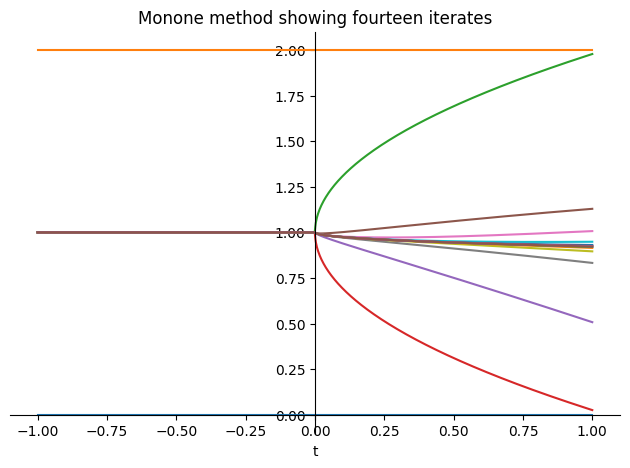

In [ ]:
p = plot(v0, w0, v1, w1, v2, w2, v3, w3, v4, w4, v5, w5, v6, w6, v7, w7, (t, -1, 1), \
     title='Monone method showing fourteen iterates', xlabel='t', ylabel=False, style='wireframe')

#p.save('example1.eps')